# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

## Imports

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset
from bedposip.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
    inspect_quantization_bits, 
    plot_quantization_bits
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope, LayerConfigScope
from hgq.utils import trace_minmax
from hgq.constraints import MinMax, Max

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Constant for training quantizers bit-width optimizations
REGULARIZER = 1e-5

# Limit VRAM GPU usage
physical_devices = tf.config.list_physical_devices('GPU')
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [11]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()


Dataset shapes:
  Train: (119999, 8, 8, 1), labels: (119999,)
  Val:   (60000, 8, 8, 1), labels: (60000,)
  Test:  (120001, 8, 8, 1), labels: (120001,)


### Encoding

In [12]:
class_names = {"lateral_L": 0, "lateral_R": 1, "supine": 2}

## Configuration

In [13]:
# Define callbacks using package function
# BetaPID dynamically adjusts beta to steer the model toward a target EBOPs budget.
callbacks = get_callbacks(
    model_name='qat',
    patience=30,
    track_ebops=True,
    target_ebops=800_000,
    init_beta=1e-7,
)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - FreeEBOPs
  - BetaPID


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [ ]:
with (
    QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
    QuantizerConfigScope(
        place='weight',
        bc=Max(6),
        ic=Max(8),
        i0=2, b0=6,
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='datalane',
        fc=Max(3),
        ic=Max(8),
        i0=3, f0=3,
        heterogeneous_axis=(),
        default_q_type='kif', overflow_mode='WRAP'
    ),
    LayerConfigScope(enable_ebops=True),  # beta managed by BetaPID callback
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()

Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 24)       │           870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_1                      │ (None, 6, 6, 24)       │           246 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_1 (Activation)        │ (None, 6, 6, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 20)       │        17,286 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_2                      │ (None, 4, 4, 20)       │           206 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_2 (Activation)        │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 36)       │        25,926 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_3                      │ (None, 2, 2, 36)       │           366 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_3 (Activation)        │ (None, 2, 2, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_max_pooling2d_1               │ (None, 1, 1, 36)       │             6 │
│ (QMaxPooling2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 26)             │         3,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_dense_1                     │ (None, 26)             │           266 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 10)             │         1,046 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_dense_2                     │ (None, 10)             │           106 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           138 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,212 (159.55 KB)

 Trainable params: 37,443 (146.26 KB)

 Non-trainable params: 12,769 (13.29 KB)

In [15]:
check_layer_trainable_params(model_qat)

qconv_1: 216
qbn_conv_1: 24
qconv_2: 4320
Layer qconv_2 is too large (4320), are you sure you want to train?
qbn_conv_2: 20
qconv_3: 6480
Layer qconv_3 is too large (6480), are you sure you want to train?
qbn_conv_3: 36
qdense_1: 936
qbn_dense_1: 26
qdense_2: 260
qbn_dense_2: 10
output: 30


### Training

Epoch 1/500


I0000 00:00:1785201283.313181   43352 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75558__.124


58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5301 - loss: 1.4472

I0000 00:00:1785201291.650305   43348 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75558__.124


59/59 ━━━━━━━━━━━━━━━━━━━━ 29s 246ms/step - accuracy: 0.6216 - loss: 1.3074 - val_accuracy: 0.4414 - val_loss: 1.5391 - learning_rate: 0.0010 - ebops: 4633220.0000 - beta: 1.0000e-07
Epoch 2/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7663 - loss: 1.0509 - val_accuracy: 0.5204 - val_loss: 1.4094 - learning_rate: 0.0010 - ebops: 4635464.0000 - beta: 1.0000e-07
Epoch 3/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8098 - loss: 0.9500 - val_accuracy: 0.5715 - val_loss: 1.0757 - learning_rate: 0.0010 - ebops: 4634840.0000 - beta: 1.0000e-07
Epoch 4/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8307 - loss: 0.8989 - val_accuracy: 0.5734 - val_loss: 1.1836 - learning_rate: 0.0010 - ebops: 4635704.0000 - beta: 1.0000e-07
Epoch 5/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8422 - loss: 0.8689 - val_accuracy: 0.6703 - val_loss: 0.8596 - learning_rate: 0.0010 - ebops: 4635704.0000 - beta: 1.0000e-07
Epoch 6/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/ste

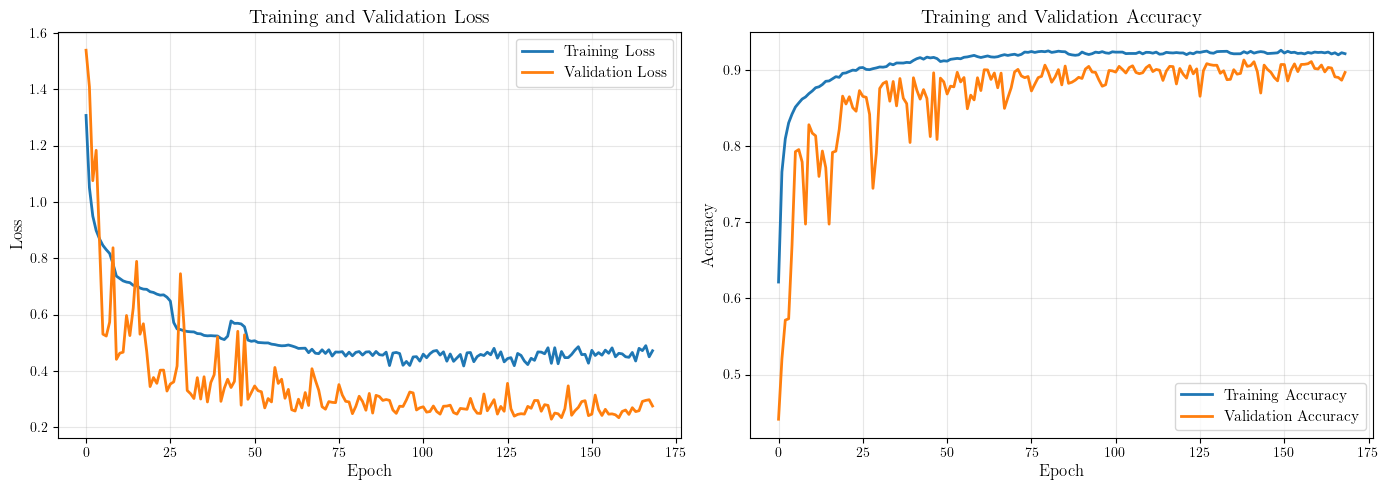

In [16]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2048, epochs=500) # Batch according to HGQ article
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

## Model Evaluation


Accuracy Report for `posture_classifier_qat`:
  Loss: 0.2319
  Accuracy: 91.13%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.9148    0.9046    0.9097     40000
   lateral_R     0.9115    0.9071    0.9093     40000
      supine     0.9079    0.9223    0.9150     40001

    accuracy                         0.9113    120001
   macro avg     0.9114    0.9113    0.9113    120001
weighted avg     0.9114    0.9113    0.9113    120001

Saved: figures/cm_posture_classifier_qat.pdf


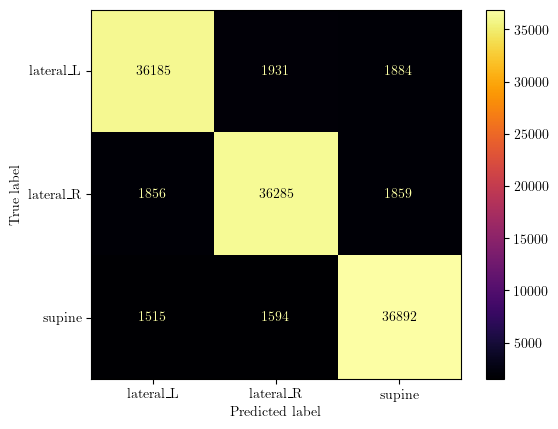

In [17]:
_, _, _ = class_report_metric(model_qat, X_test, y_test, class_names, save=True)

In [18]:
# From larger_jet_tagger

# When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. 
trace_minmax(model_qat, X_train, batch_size=2048, reset=True)
ebops = trace_minmax(model_qat, X_val, batch_size=2048, reset=False)

lut_pred = np.exp(0.985 * np.log(ebops))
dsp_pred = (ebops - lut_pred) / 55

print("Resource Estimation Report")
print("="*40)
print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

Resource Estimation Report

EBOPs: 2950328 
LUTs: 2359512 
DSPs: 10742


In [19]:
## Determine accuracy of Keras model, after trace
_, _, _ = class_report_metric(model_qat, X_test, y_test, class_names, show_report=False, show_cm=False, save=False)


Accuracy Report for `posture_classifier_qat`:
  Loss: 0.2326
  Accuracy: 91.12%



Quantization Bit-width Report:
pressure_map: InputLayer (no quantizers)

qconv_1 (QConv2D):
  iq: bits=7.00, fbits=7.00, type=kif
  kq: bits=5.73, fbits=6.73, type=kbi

qbn_conv_1 (QBatchNormalization):
  iq: bits=8.00, fbits=9.00, type=kif
  kq: bits=5.96, fbits=6.96, type=kbi
  bq: bits=4.54, fbits=5.54, type=kbi
qconv_act_1: Activation (no quantizers)

qconv_2 (QConv2D):
  iq: bits=5.00, fbits=5.00, type=kif
  kq: bits=5.05, fbits=6.05, type=kbi

qbn_conv_2 (QBatchNormalization):
  iq: bits=8.00, fbits=9.00, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi
  bq: bits=5.00, fbits=6.00, type=kbi
qconv_act_2: Activation (no quantizers)

qconv_3 (QConv2D):
  iq: bits=5.00, fbits=5.00, type=kif
  kq: bits=5.92, fbits=6.92, type=kbi

qbn_conv_3 (QBatchNormalization):
  iq: bits=9.00, fbits=10.00, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi
  bq: bits=4.89, fbits=5.89, type=kbi
qconv_act_3: Activation (no quantizers)
q_max_pooling2d_1: QMaxPooling2D (no quantizers)
flatten_1: Flatten (no

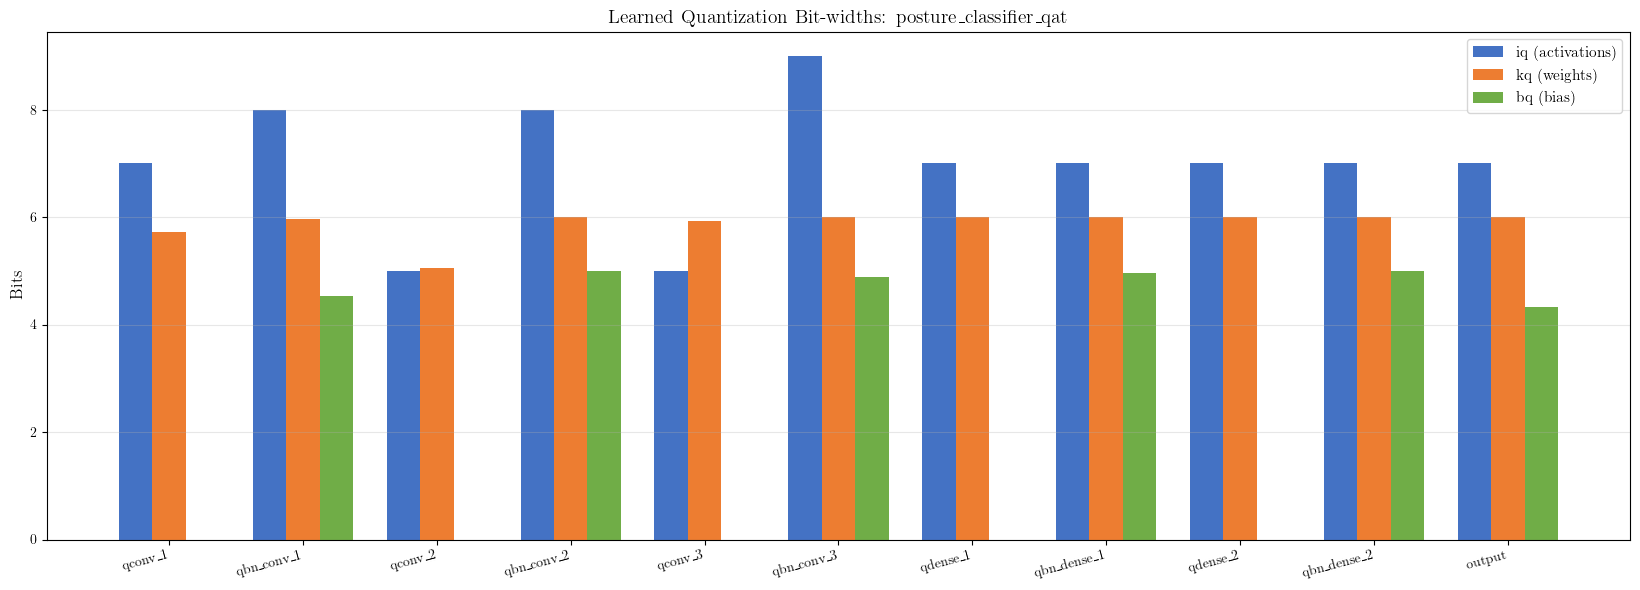

In [22]:
# Inspect learned quantization bit-widths
bits_info = inspect_quantization_bits(model_qat, report=True)

plot_quantization_bits(model_qat, bits_info=bits_info, save=True)

## Model Saving

In [23]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 50,212
